# Лабораторная 1. Классификация растровых изображений с помощью kNN

**Задание.** Написать программу для распознавания растровых изображений, используя
метод ближайшего соседа. Реализовать программно равномерное и неравномерное
зашумление изображений и сравнить процент распознавания для используемых норм в
случаях распознавания растровых бинарных изображений и изображений в градациях
серого цвета для различных `k`. Сравнить результаты применения разных
мер близости.

## 1. Теория

### Данные

MNIST, изображения $28 \times 28$ в градациях серого, 10 классов. Берётся
стратифицированная подвыборка: 2000 обучающих и 300 тестовых изображений, по
одинаковому числу на класс. Изображение разворачивается в вектор длины
$m = 784$, значения пикселей делятся на 255.

### Метод ближайшего соседа

Дана обучающая выборка $\{(x^{(i)}, y^{(i)})\}_{i=1}^{N}$, где
$x^{(i)} \in \mathbb{R}^m$ это вектор признаков, $y^{(i)}$ метка класса. Для
нового объекта $x$ находятся $k$ ближайших к нему элементов выборки по выбранной
мере близости $\rho$, и $x$ относится к классу, преобладающему среди них:

$$\hat y(x) = \arg\max_{c} \sum_{i \in N_k(x)} w_i \cdot [\,y^{(i)} = c\,],$$

где $N_k(x)$ это индексы $k$ ближайших элементов. При $w_i \equiv 1$ это простое
голосование, при $w_i = 1/\rho(x, x^{(i)})$ взвешенное. Обучения нет, стоимость
одного предсказания $O(Nm)$.

### Меры близости

| Мера | Формула |
|------|---------|
| $L_1$, манхэттенская | $\sum_j \lvert x_j - z_j \rvert$ |
| $L_2$, евклидова | $\sqrt{\sum_j (x_j - z_j)^2}$ |
| $L_\infty$, Чебышёва | $\max_j \lvert x_j - z_j \rvert$ |
| косинусная | $1 - \dfrac{\langle x, z\rangle}{\lVert x\rVert\,\lVert z\rVert}$ |

Квадрат евклидова расстояния упорядочивает соседей так же, как $L_2$, поэтому
отдельно не берётся. Для бинарных изображений расстояние Хэмминга совпадает с
$L_1$, а $L_2^2 = L_1$, поэтому $L_1$ и $L_2$ дают одинаковый порядок соседей.

### Модели зашумления

Равномерное: каждый пиксель независимо с вероятностью $p$ заменяется случайным
значением из $[0, 255]$. Неравномерное: квадратный блок случайного положения
целиком заливается случайными значениями.

### Бинаризация

Изображение переводится в бинарное порогом $x_j > \theta$ при $\theta = 128$.

### Что перебирается

| Гиперпараметр | Значения |
|---|---|
| представление | градации серого, бинарное |
| зашумление | нет; равномерное, $p = 0.1$ и $0.3$; блок $8 \times 8$ и $12 \times 12$ |
| мера близости | $L_1$, $L_2$, $L_\infty$, косинусная |
| $k$ | 1, 3, 5, 7, 9 |
| голосование | простое, взвешенное |

### Мера качества

Доля верных ответов $\mathrm{accuracy} = \frac1n \sum_k [\,\hat y_k = y_k\,]$.

## 2. Загрузка данных

In [1]:
import os
import struct
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

RNG = np.random.default_rng(20260905)
plt.rcParams['figure.dpi'] = 110

In [2]:
def read_idx(path):
    with open(path, 'rb') as f:
        magic, = struct.unpack('>I', f.read(4))
        dims = struct.unpack('>' + 'I' * (magic & 0xff), f.read(4 * (magic & 0xff)))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(dims)


def mnist_dir():
    candidates = [os.environ.get('MNIST_DIR'),
                  '../../bachelor/Perceptron/data_generation/MNIST/raw',
                  'data/MNIST/raw']
    for c in candidates:
        if c and Path(c, 'train-images-idx3-ubyte').exists():
            return Path(c)
    raise FileNotFoundError('не найдены файлы MNIST')


D = mnist_dir()
X_train_full = read_idx(D / 'train-images-idx3-ubyte')
y_train_full = read_idx(D / 'train-labels-idx1-ubyte')
X_test_full = read_idx(D / 't10k-images-idx3-ubyte')
y_test_full = read_idx(D / 't10k-labels-idx1-ubyte')

print(f'обучающая выборка: {X_train_full.shape}, тестовая: {X_test_full.shape}')
print(f'классы: {np.bincount(y_train_full)}')

обучающая выборка: (60000, 28, 28), тестовая: (10000, 28, 28)
классы: [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


In [3]:
def stratified(X, y, per_class, rng):
    idx = np.concatenate([rng.choice(np.flatnonzero(y == c), per_class, replace=False)
                          for c in range(10)])
    rng.shuffle(idx)
    return X[idx], y[idx]


X_tr, y_tr = stratified(X_train_full, y_train_full, 200, RNG)
X_te, y_te = stratified(X_test_full, y_test_full, 30, RNG)
print(f'подвыборка: обучающая {X_tr.shape}, тестовая {X_te.shape}')
print(f'по классам: {np.bincount(y_tr)}')

подвыборка: обучающая (2000, 28, 28), тестовая (300, 28, 28)
по классам: [200 200 200 200 200 200 200 200 200 200]


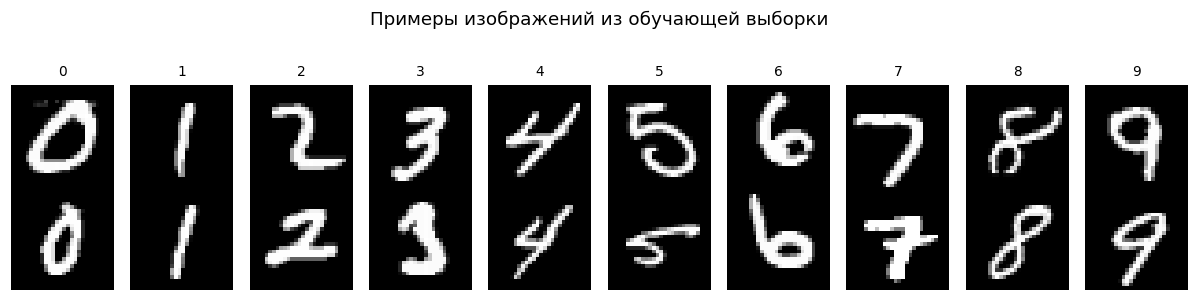

In [4]:
fig, axes = plt.subplots(2, 10, figsize=(11, 2.6))
for c in range(10):
    for row in range(2):
        j = np.flatnonzero(y_tr == c)[row]
        axes[row, c].imshow(X_tr[j], cmap='gray')
        axes[row, c].axis('off')
    axes[0, c].set_title(str(c), fontsize=9)
fig.suptitle('Примеры изображений из обучающей выборки', y=1.04)
plt.tight_layout()
plt.show()

## 3. Реализация метода ближайшего соседа

In [5]:
def point_distances(x, B, metric):
    """Расстояния от вектора x до каждой строки матрицы B."""
    # x - B: из x вычитается каждая строка B, получается матрица разностей
    # той же формы, что B, и дальше по её строкам берётся нужная норма
    if metric == 'l1':
        return np.abs(x - B).sum(axis=1)
    if metric == 'l2':
        return np.sqrt(((x - B) ** 2).sum(axis=1))
    if metric == 'linf':
        return np.abs(x - B).max(axis=1)
    if metric == 'cosine':
        dot = (x * B).sum(axis=1)
        norms = np.linalg.norm(x) * np.linalg.norm(B, axis=1)
        return 1.0 - dot / (norms + 1e-12)
    raise ValueError(metric)


def distances(A, B, metric):
    """Матрица расстояний: в строке i расстояния от запроса A[i] до всех объектов B."""
    A = A.astype(np.float32)
    B = B.astype(np.float32)
    out = np.empty((len(A), len(B)), dtype=np.float32)
    for i in range(len(A)):
        out[i] = point_distances(A[i], B, metric)
    return out


def knn_predict(dist, y_train, k, weighted):
    """Предсказание по готовой матрице расстояний."""
    pred = np.zeros(len(dist), dtype=int)
    for i in range(len(dist)):
        nn = np.argsort(dist[i])[:k]  # номера k ближайших объектов обучающей выборки
        votes = np.zeros(10)
        for j in nn:
            # 1e-9 страхует от нулевого расстояния при совпадении изображений
            w = 1.0 / (dist[i, j] + 1e-9) if weighted else 1.0
            votes[y_train[j]] += w
        pred[i] = votes.argmax()
    return pred

In [6]:
flat_tr = X_tr.reshape(len(X_tr), -1) / 255.0
flat_te = X_te.reshape(len(X_te), -1) / 255.0

mine = knn_predict(distances(flat_te, flat_tr, 'l2'), y_tr, k=5, weighted=False)
ref = KNeighborsClassifier(n_neighbors=5, metric='euclidean').fit(flat_tr, y_tr).predict(flat_te)
print(f'совпадение с sklearn: {np.mean(mine == ref):.4f}')
print(f'accuracy собственной реализации: {np.mean(mine == y_te):.4f}')

совпадение с sklearn: 1.0000
accuracy собственной реализации: 0.8867


## 4. Модели зашумления

In [7]:
def uniform_noise(X, p, rng):
    """Каждый пиксель независимо с вероятностью p заменяется случайным значением."""
    X = X.copy()
    mask = rng.random(X.shape) < p
    X[mask] = rng.integers(0, 256, mask.sum(), dtype=np.uint8)
    return X


def blot_noise(X, size, rng):
    """Квадратный блок случайного положения заливается шумом."""
    X = X.copy()
    n, h, w = X.shape
    r0 = rng.integers(0, h - size + 1, n)
    c0 = rng.integers(0, w - size + 1, n)
    for i in range(n):
        X[i, r0[i]:r0[i] + size, c0[i]:c0[i] + size] = rng.integers(0, 256, (size, size))
    return X


def binarize(X, threshold=128):
    return (X > threshold).astype(np.uint8) * 255

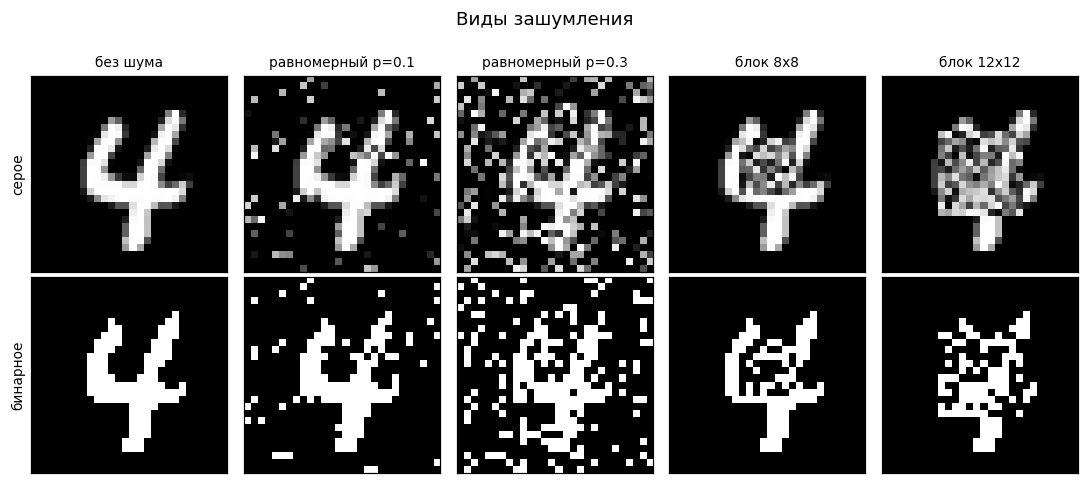

доля испорченных пикселей:
  без шума             0.000
  равномерный p=0.1    0.099
  равномерный p=0.3    0.300
  блок 8x8             0.081
  блок 12x12           0.183


In [8]:
conditions = {
    'без шума': lambda X, rng: X.copy(),
    'равномерный p=0.1': lambda X, rng: uniform_noise(X, 0.1, rng),
    'равномерный p=0.3': lambda X, rng: uniform_noise(X, 0.3, rng),
    'блок 8x8': lambda X, rng: blot_noise(X, 8, rng),
    'блок 12x12': lambda X, rng: blot_noise(X, 12, rng),
}

fig, axes = plt.subplots(2, 5, figsize=(10, 4.4))
for col, (name, f) in enumerate(conditions.items()):
    noisy = f(X_te[:1], np.random.default_rng(1))[0]
    axes[0, col].imshow(noisy, cmap='gray')
    axes[1, col].imshow(binarize(noisy), cmap='gray')
    axes[0, col].set_title(name, fontsize=9)
    for row in range(2):
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
axes[0, 0].set_ylabel('серое', fontsize=9)
axes[1, 0].set_ylabel('бинарное', fontsize=9)
fig.suptitle('Виды зашумления', y=1.0)
plt.tight_layout()
plt.show()

print('доля испорченных пикселей:')
for name, f in conditions.items():
    noisy = f(X_te, np.random.default_rng(1))
    print(f'  {name:20s} {np.mean(noisy != X_te):.3f}')

## 5. Эксперименты

In [9]:
METRICS = ['l1', 'l2', 'linf', 'cosine']
KS = [1, 3, 5, 7, 9]

rows = []
for repr_name, prep in [('серое', lambda X: X), ('бинарное', binarize)]:
    train = prep(X_tr).reshape(len(X_tr), -1).astype(np.float32) / 255.0
    for cond_name, noise in conditions.items():
        noisy = noise(X_te, np.random.default_rng(20260905))
        test = prep(noisy).reshape(len(X_te), -1).astype(np.float32) / 255.0
        for metric in METRICS:
            dist = distances(test, train, metric)
            for k in KS:
                for weighted in (False, True):
                    pred = knn_predict(dist, y_tr, k, weighted)
                    rows.append(dict(representation=repr_name, condition=cond_name,
                                     metric=metric, k=k, weighted=weighted,
                                     accuracy=float(np.mean(pred == y_te))))

In [10]:
df = pd.DataFrame(rows)
df.to_csv('results.csv', index=False)
print(f'{len(df)} конфигураций')

400 конфигураций


## 6. Результаты

### 6.1 Меры близости на чистых изображениях

In [11]:
clean = df[(df.condition == 'без шума') & (~df.weighted)]
pivot = clean.pivot_table(index=['representation', 'metric'], columns='k', values='accuracy')
print(pivot.round(3).to_string())

k                          1      3      5      7      9
representation metric                                   
бинарное       cosine  0.907  0.900  0.900  0.890  0.893
               l1      0.877  0.887  0.900  0.883  0.877
               l2      0.877  0.887  0.900  0.883  0.877
               linf    0.100  0.100  0.100  0.100  0.100
серое          cosine  0.910  0.910  0.900  0.903  0.893
               l1      0.900  0.883  0.877  0.880  0.873
               l2      0.930  0.907  0.887  0.893  0.873
               linf    0.567  0.540  0.540  0.550  0.533


### 6.2 Устойчивость мер близости к шуму

In [12]:
best_k = df[~df.weighted].groupby(['representation', 'condition', 'metric'])['accuracy'].max()
print(best_k.unstack('metric').round(3).to_string())

metric                            cosine     l1     l2   linf
representation condition                                     
бинарное       без шума            0.907  0.900  0.900  0.100
               блок 12x12          0.757  0.803  0.803  0.100
               блок 8x8            0.873  0.870  0.870  0.100
               равномерный p=0.1   0.897  0.880  0.880  0.100
               равномерный p=0.3   0.877  0.873  0.873  0.100
серое          без шума            0.910  0.900  0.930  0.567
               блок 12x12          0.783  0.853  0.867  0.367
               блок 8x8            0.877  0.890  0.900  0.483
               равномерный p=0.1   0.903  0.900  0.923  0.390
               равномерный p=0.3   0.887  0.903  0.910  0.240


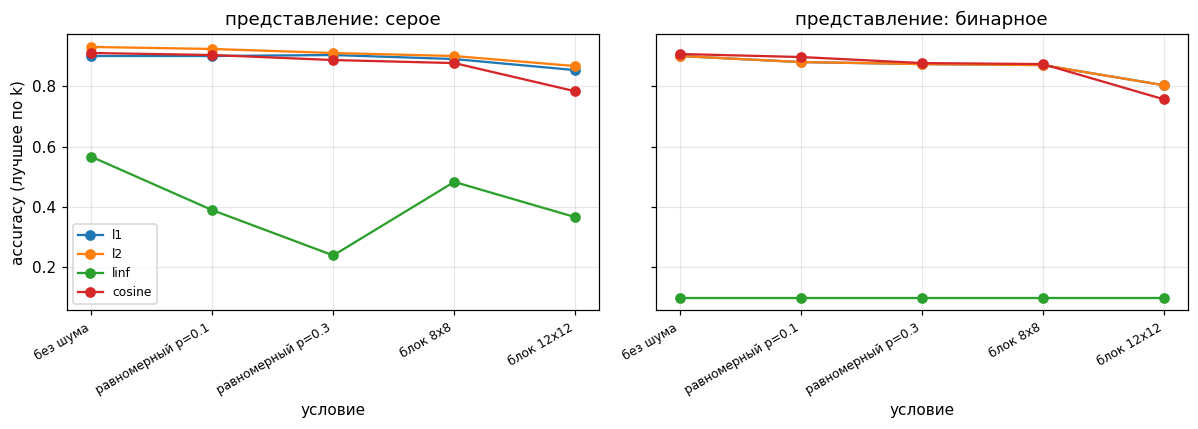

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
order = list(conditions.keys())
for ax, repr_name in zip(axes, ['серое', 'бинарное']):
    sub = df[(df.representation == repr_name) & (~df.weighted)]
    for metric in METRICS:
        acc = [sub[(sub.condition == c) & (sub.metric == metric)].accuracy.max() for c in order]
        ax.plot(range(len(order)), acc, marker='o', label=metric)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=30, ha='right', fontsize=8)
    ax.set_title(f'представление: {repr_name}')
    ax.set_xlabel('условие')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('accuracy (лучшее по k)')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

### 6.3 Зависимость от k

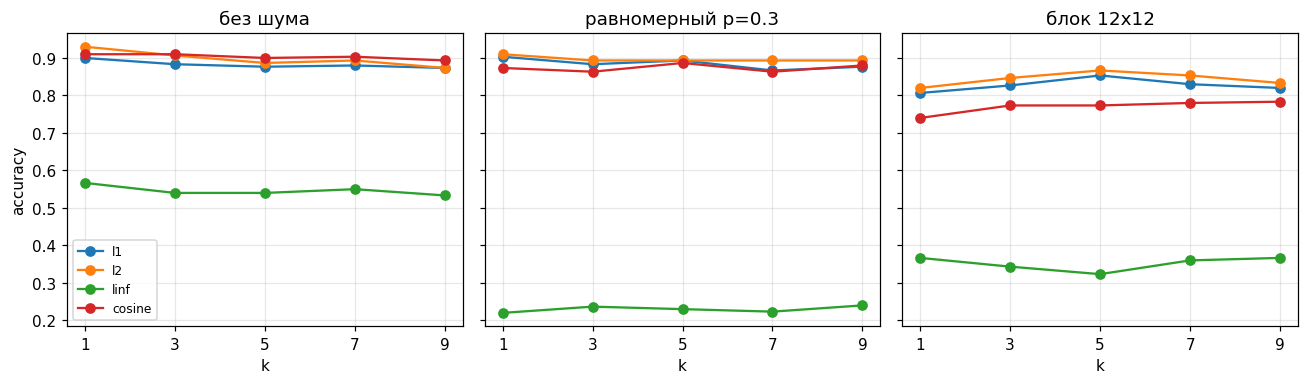

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, cond in zip(axes, ['без шума', 'равномерный p=0.3', 'блок 12x12']):
    sub = df[(df.representation == 'серое') & (df.condition == cond) & (~df.weighted)]
    for metric in METRICS:
        s = sub[sub.metric == metric].sort_values('k')
        ax.plot(s.k, s.accuracy, marker='o', label=metric)
    ax.set_title(cond)
    ax.set_xlabel('k')
    ax.set_xticks(KS)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('accuracy')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

### 6.4 Взвешенное голосование

In [15]:
cmp = df.pivot_table(index=['representation', 'condition', 'metric', 'k'],
                     columns='weighted', values='accuracy')
cmp['разность'] = cmp[True] - cmp[False]
print(f'взвешивание помогает в {(cmp["разность"] > 0).mean():.1%} конфигураций, '
      f'средний прирост {cmp["разность"].mean():+.4f}, '
      f'максимальный {cmp["разность"].max():+.4f}')
print('\nсредний прирост по k:')
print(cmp.groupby('k')['разность'].mean().round(4).to_string())

взвешивание помогает в 50.0% конфигураций, средний прирост +0.0055, максимальный +0.0467

средний прирост по k:
k
1    0.0000
3    0.0072
5    0.0075
7    0.0076
9    0.0052


### 6.5 Матрица ошибок лучшей конфигурации

лучшая конфигурация без шума: серое, l2, k = 1, взвешенное голосование: нет, accuracy 0.930


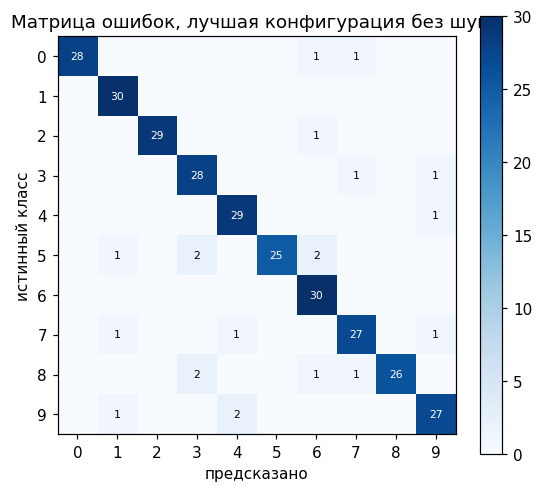

              precision    recall  f1-score   support

           0      1.000     0.933     0.966        30
           1      0.909     1.000     0.952        30
           2      1.000     0.967     0.983        30
           3      0.875     0.933     0.903        30
           4      0.906     0.967     0.935        30
           5      1.000     0.833     0.909        30
           6      0.857     1.000     0.923        30
           7      0.900     0.900     0.900        30
           8      1.000     0.867     0.929        30
           9      0.900     0.900     0.900        30

    accuracy                          0.930       300
   macro avg      0.935     0.930     0.930       300
weighted avg      0.935     0.930     0.930       300



In [16]:
best = df.loc[df[df.condition == 'без шума'].accuracy.idxmax()]
print(f'лучшая конфигурация без шума: {best.representation}, {best.metric}, k = {best.k}, '
      f'взвешенное голосование: {"да" if best.weighted else "нет"}, '
      f'accuracy {best.accuracy:.3f}')

prep = (lambda X: X) if best.representation == 'серое' else binarize
train = prep(X_tr).reshape(len(X_tr), -1).astype(np.float32) / 255.0
test = prep(X_te).reshape(len(X_te), -1).astype(np.float32) / 255.0
pred = knn_predict(distances(test, train, best.metric), y_tr, int(best.k), bool(best.weighted))

cm = confusion_matrix(y_te, pred)
fig, ax = plt.subplots(figsize=(5.2, 4.6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xlabel('предсказано')
ax.set_ylabel('истинный класс')
ax.set_title('Матрица ошибок, лучшая конфигурация без шума')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
for i in range(10):
    for j in range(10):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=7,
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.show()

print(classification_report(y_te, pred, digits=3))